In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_excel("/Users/emrekuru/Developer/Kanzy/Research/RAG-Mixer/evaluation/data/updated_dataset.xlsx", index_col=0)

In [3]:
predictions = pd.read_excel("predictions/predictions_rerank.xlsx", index_col="query")

In [4]:
predictions = predictions[predictions.index.isin(dataset.index)]

In [20]:
predictions

,MULTIMODAL-MULTI_ndcg,MULTIMODAL-MULTI_mrr,MULTIMODAL-MULTI_precision,MULTIMODAL-MULTI_recall,MULTIMODAL-MULTI_latency,MULTIMODAL-SINGLE_ndcg,MULTIMODAL-SINGLE_mrr,MULTIMODAL-SINGLE_precision,MULTIMODAL-SINGLE_recall,MULTIMODAL-SINGLE_latency,...,true_ndcg_TEXT_RERANK,pred_prob_MULTIMODAL_RERANK,true_ndcg_MULTIMODAL_RERANK,predicted_label,predicted_strategy,true_label,true_strategy,predicted_ndcg,oracle_ndcg,regret
query,,,,,,,,,,,,,,,,,,,,,
What types of financial instruments does IBM consider as debt securities in its financial report for 2013?,0.430677,0.250000,0.2,1.0,7.181078,0.00000,0.0,0.0,0.0,0.539867,...,0.630930,0.631822,0.430677,1,MULTIMODAL_RERANK,0,TEXT_RERANK,0.430677,0.63093,0.200253
"What types of bonds did IBM issue on January 11, 2019, and what was the total amount?",1.000000,1.000000,0.2,1.0,6.064459,0.00000,0.0,0.0,0.0,0.470906,...,0.386853,0.593285,1.000000,1,MULTIMODAL_RERANK,1,MULTIMODAL_RERANK,1.000000,1.00000,0.000000
What services does IBM offer to help clients assess their risk and compliance against industry guidelines?,1.000000,1.000000,0.2,1.0,4.065866,1.00000,1.0,0.2,1.0,0.029978,...,1.000000,0.578567,1.000000,1,MULTIMODAL_RERANK,0,TEXT_RERANK,1.000000,1.00000,0.000000
How much were the fully reserved financing receivables in major markets for IBM in 2016?,1.000000,1.000000,0.2,1.0,7.657306,0.00000,0.0,0.0,0.0,0.065894,...,1.000000,0.567577,1.000000,1,MULTIMODAL_RERANK,0,TEXT_RERANK,1.000000,1.00000,0.000000
How many shares were repurchased by IBM in 2018 and 2019?,0.500000,0.333333,0.2,1.0,6.411813,0.00000,0.0,0.0,0.0,0.294893,...,0.430677,0.621369,0.500000,1,MULTIMODAL_RERANK,1,MULTIMODAL_RERANK,0.500000,0.50000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
what is the main airport in london england,1.000000,1.000000,0.2,1.0,17.280460,0.00000,0.0,0.0,0.0,0.271942,...,1.000000,0.480235,1.000000,0,TEXT_RERANK,0,TEXT_RERANK,1.000000,1.00000,0.000000
the part of the temporal lobe that receives and interprets auditory information,1.000000,1.000000,0.2,1.0,19.398999,1.00000,1.0,0.2,1.0,0.318856,...,1.000000,0.475605,1.000000,0,TEXT_RERANK,0,TEXT_RERANK,1.000000,1.00000,0.000000
who sang i just died in your arms,1.000000,1.000000,0.2,1.0,17.801794,1.00000,1.0,0.2,1.0,0.241902,...,1.000000,0.469520,1.000000,0,TEXT_RERANK,0,TEXT_RERANK,1.000000,1.00000,0.000000


In [5]:
dataset = dataset.loc[predictions.index]

In [6]:
dataset.drop(columns=["DATASET"]).mean()

MULTIMODAL-MULTI_ndcg          0.736669
MULTIMODAL-MULTI_mrr           0.704189
MULTIMODAL-MULTI_precision     0.167764
MULTIMODAL-MULTI_recall        0.834068
MULTIMODAL-MULTI_latency       8.283272
MULTIMODAL-SINGLE_ndcg         0.666021
MULTIMODAL-SINGLE_mrr          0.628817
MULTIMODAL-SINGLE_precision    0.156642
MULTIMODAL-SINGLE_recall       0.778610
MULTIMODAL-SINGLE_latency      0.384490
TEXT-MULTI_ndcg                0.596482
TEXT-MULTI_mrr                 0.559999
TEXT-MULTI_precision           0.141735
TEXT-MULTI_recall              0.706039
TEXT-MULTI_latency             2.796394
TEXT-SINGLE_ndcg               0.492429
TEXT-SINGLE_mrr                0.456364
TEXT-SINGLE_precision          0.120668
TEXT-SINGLE_recall             0.601292
TEXT-SINGLE_latency            0.455017
MULTIMODAL_RERANK_ndcg         0.732981
MULTIMODAL_RERANK_mrr          0.700727
MULTIMODAL_RERANK_recall       0.829777
MULTIMODAL_RERANK_precision    0.166917
MULTIMODAL_RERANK_latency      1.120659


# ORACLE 

In [7]:
def best_pipeline_by_ndcg(row):
    import math
    candidates = []
    # Only route between rerank pipelines
    router_pipelines = ['TEXT_RERANK', 'MULTIMODAL_RERANK']
    
    for prefix in router_pipelines:
        ndcg_col = f'{prefix}_ndcg'
        lat_col = f'{prefix}_latency'
        
        if ndcg_col not in row.index:
            continue
            
        ndcg = row[ndcg_col]
        if pd.isna(ndcg):
            continue
            
        lat = row.get(lat_col, math.inf)
        if pd.isna(lat):
            lat = math.inf
            
        candidates.append((prefix, float(ndcg), float(lat)))
    
    if not candidates:
        return None
    
    max_ndcg = max(c[1] for c in candidates)
    top = [c for c in candidates if c[1] == max_ndcg]
    best = min(top, key=lambda x: x[2])
    return best[0]

In [8]:
# Build an oracle DataFrame using the best pipeline per row (ndcg; tie -> lowest latency)
def build_oracle_row(row):
    best = best_pipeline_by_ndcg(row)
    metrics = ['ndcg','mrr','precision','recall','latency']
    if best is None:
        return pd.Series({'pipeline': None, **{m: pd.NA for m in metrics}, 'DATASET': row.get('DATASET')})
    values = {m: row.get(f'{best}_{m}') for m in metrics}
    return pd.Series({'pipeline': best, **values, 'DATASET': row.get('DATASET')})

In [9]:
oracle = dataset.apply(build_oracle_row, axis=1)
oracle = oracle[['pipeline','ndcg','mrr','precision','recall','latency','DATASET']]

In [22]:
arm_map = {
    "TEXT_RERANK" : 0,
    "MULTIMODAL_RERANK" : 1
}

In [24]:
oracle["predicted_label"] = oracle["pipeline"].map(arm_map)

# RAG-MİXER

In [10]:
# Build RAG-Mixer DataFrame using predicted_strategy from predictions
def build_rag_mixer_row(row):
    """Build RAG-Mixer row using the predicted strategy."""
    strat = row['predicted_strategy']
    metrics = ['ndcg', 'mrr', 'precision', 'recall', 'latency']
    if pd.isna(strat):
        return pd.Series({'pipeline': None, **{m: pd.NA for m in metrics}, 'DATASET': row.get('DATASET')})
    
    # Get the corresponding metrics from the dataset for this query
    query = row.name
    if query in dataset.index:
        values = {m: dataset.loc[query, f'{strat}_{m}'] for m in metrics}
    else:
        values = {m: pd.NA for m in metrics}
    return pd.Series({'pipeline': strat, **values, 'DATASET': row.get('DATASET')})
rag_mixer = predictions.apply(build_rag_mixer_row, axis=1)
rag_mixer = rag_mixer[['pipeline', 'ndcg', 'mrr', 'precision', 'recall', 'latency', 'DATASET']]

# Significance Tests

In [11]:
from significance_tests import compare_models

In [12]:
models = ["MULTIMODAL-MULTI", "MULTIMODAL-SINGLE", "TEXT-MULTI", "TEXT-SINGLE", "TEXT_RERANK", "MULTIMODAL_RERANK", "RAG-MIXER"]

In [13]:
for metric_idx, metric in enumerate(["ndcg","mrr","precision","recall"]):
    filtered_columns = [column for column in dataset.columns if column.endswith(metric)]
    filtered_data = dataset[filtered_columns]
    value_lists = []

    for i,column in enumerate(filtered_data.columns):
        value_lists.append([filtered_data[column].values])

    value_lists.append([rag_mixer[metric].values])
    
    df = pd.DataFrame(value_lists, index=models, columns=[metric])
    display(compare_models(df))

,Metric,Group Test,Group p,Best Method,Compared Method,Pair Test,Pair p,Significant,Effect Size (Cohen's d),Effect Interpretation
0,ndcg,Friedman Test,0.0,RAG-MIXER,MULTIMODAL-MULTI,Wilcoxon Signed-Rank Test,5.890576e-04,True,0.010812,negligible
1,ndcg,Friedman Test,0.0,RAG-MIXER,MULTIMODAL-SINGLE,Wilcoxon Signed-Rank Test,9.651407e-44,True,0.192582,negligible
2,ndcg,Friedman Test,0.0,RAG-MIXER,TEXT-MULTI,Wilcoxon Signed-Rank Test,3.930849e-142,True,0.359516,small
3,ndcg,Friedman Test,0.0,RAG-MIXER,TEXT-SINGLE,Wilcoxon Signed-Rank Test,0.000000e+00,True,0.609056,medium
4,ndcg,Friedman Test,0.0,RAG-MIXER,TEXT_RERANK,Wilcoxon Signed-Rank Test,4.956264e-10,True,0.020593,negligible
5,ndcg,Friedman Test,0.0,RAG-MIXER,MULTIMODAL_RERANK,Wilcoxon Signed-Rank Test,1.540145e-250,True,0.337900,small


,Metric,Group Test,Group p,Best Method,Compared Method,Pair Test,Pair p,Significant,Effect Size (Cohen's d),Effect Interpretation
0,mrr,Friedman Test,0.0,RAG-MIXER,MULTIMODAL-MULTI,Wilcoxon Signed-Rank Test,1.368034e-03,True,0.010408,negligible
1,mrr,Friedman Test,0.0,RAG-MIXER,MULTIMODAL-SINGLE,Wilcoxon Signed-Rank Test,3.247870e-46,True,0.195128,negligible
2,mrr,Friedman Test,0.0,RAG-MIXER,TEXT-MULTI,Wilcoxon Signed-Rank Test,3.464856e-135,True,0.355586,small
3,mrr,Friedman Test,0.0,RAG-MIXER,TEXT-SINGLE,Wilcoxon Signed-Rank Test,0.000000e+00,True,0.601064,medium
4,mrr,Friedman Test,0.0,RAG-MIXER,TEXT_RERANK,Wilcoxon Signed-Rank Test,3.184643e-08,True,0.019102,negligible
5,mrr,Friedman Test,0.0,RAG-MIXER,MULTIMODAL_RERANK,Wilcoxon Signed-Rank Test,1.863153e-225,True,0.325377,small


,Metric,Group Test,Group p,Best Method,Compared Method,Pair Test,Pair p,Significant,Effect Size (Cohen's d),Effect Interpretation
0,precision,Friedman Test,0.0,RAG-MIXER,MULTIMODAL-MULTI,Wilcoxon Signed-Rank Test,3.500568e-02,True,0.010308,negligible
1,precision,Friedman Test,0.0,RAG-MIXER,MULTIMODAL-SINGLE,Wilcoxon Signed-Rank Test,2.950934e-26,True,0.149763,negligible
2,precision,Friedman Test,0.0,RAG-MIXER,TEXT-MULTI,Wilcoxon Signed-Rank Test,2.533208e-109,True,0.320007,small
3,precision,Friedman Test,0.0,RAG-MIXER,TEXT-SINGLE,Wilcoxon Signed-Rank Test,2.077429e-282,True,0.547836,medium
4,precision,Friedman Test,0.0,RAG-MIXER,TEXT_RERANK,Wilcoxon Signed-Rank Test,2.986721e-08,True,0.021445,negligible
5,precision,Friedman Test,0.0,RAG-MIXER,MULTIMODAL_RERANK,Wilcoxon Signed-Rank Test,1.301086e-199,True,0.327241,small


,Metric,Group Test,Group p,Best Method,Compared Method,Pair Test,Pair p,Significant,Effect Size (Cohen's d),Effect Interpretation
0,recall,Friedman Test,0.0,RAG-MIXER,MULTIMODAL-MULTI,Wilcoxon Signed-Rank Test,3.953419e-02,True,0.010336,negligible
1,recall,Friedman Test,0.0,RAG-MIXER,MULTIMODAL-SINGLE,Wilcoxon Signed-Rank Test,2.324042e-27,True,0.151313,negligible
2,recall,Friedman Test,0.0,RAG-MIXER,TEXT-MULTI,Wilcoxon Signed-Rank Test,2.285599e-109,True,0.318573,small
3,recall,Friedman Test,0.0,RAG-MIXER,TEXT-SINGLE,Wilcoxon Signed-Rank Test,2.619495e-282,True,0.546607,medium
4,recall,Friedman Test,0.0,RAG-MIXER,TEXT_RERANK,Wilcoxon Signed-Rank Test,2.986721e-08,True,0.021832,negligible
5,recall,Friedman Test,0.0,RAG-MIXER,MULTIMODAL_RERANK,Wilcoxon Signed-Rank Test,1.915944e-201,True,0.328255,small


# Heatmaps

In [14]:
ARM_MAP = {
    "MULTIMODAL-MULTI" : 0 ,
    "MULTIMODAL-SINGLE" : 1,
    "TEXT-MULTI" : 2 ,
    "TEXT-SINGLE" : 3
}

# For router (rerank pipelines only)
ROUTER_ARM_MAP = {
    "TEXT-RERANK" : 0,
    "MULTIMODAL-RERANK" : 1
}

IRouterLM (λ=0.1) Reward Heatmap:


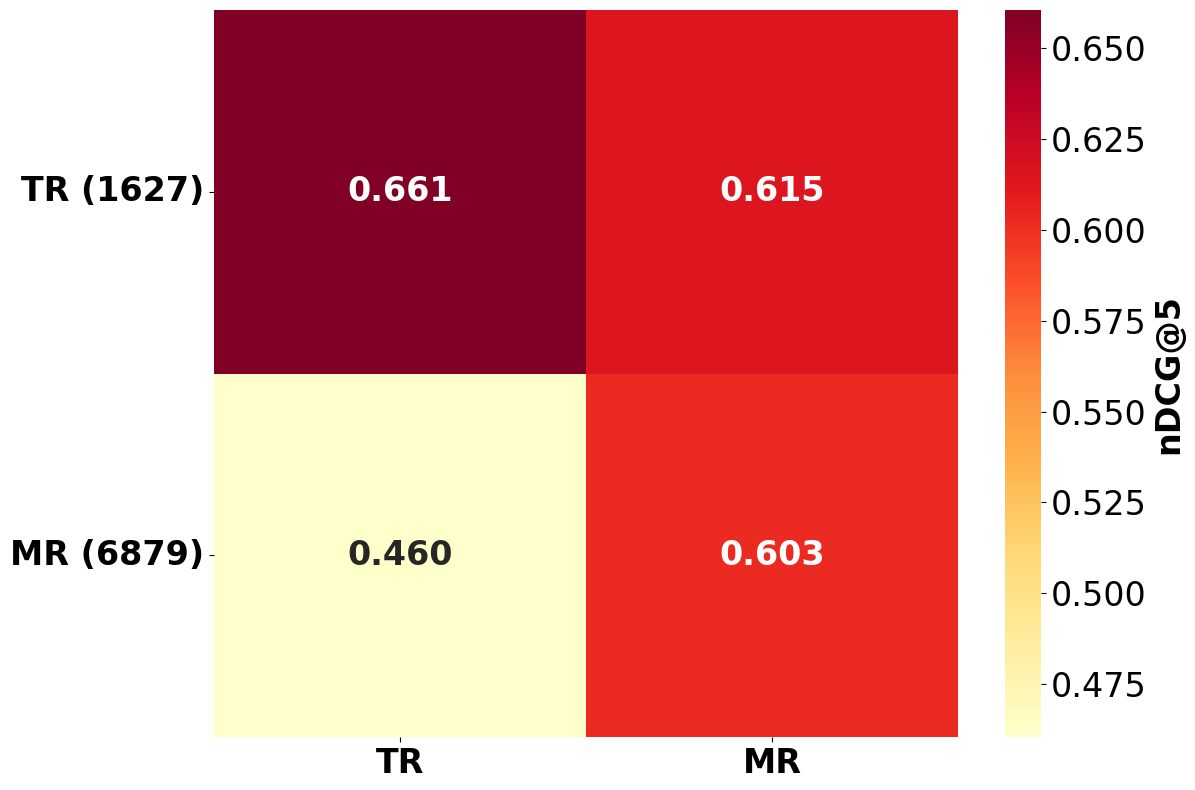

In [15]:
# Reward-based heatmap for lambda=0.1
from heatmap import plot_reward_heatmap

# Load predictions for lambda=0.1
predictions = pd.read_excel("predictions/predictions_rerank.xlsx", index_col="query")
predictions = predictions[predictions.index.isin(dataset.index)]

# Plot reward heatmap for IRouterLM - shows that router selects pipeline with highest reward
print("IRouterLM (λ=0.1) Reward Heatmap:")
plot_reward_heatmap(predictions, dataset, lambda_val=0.1)

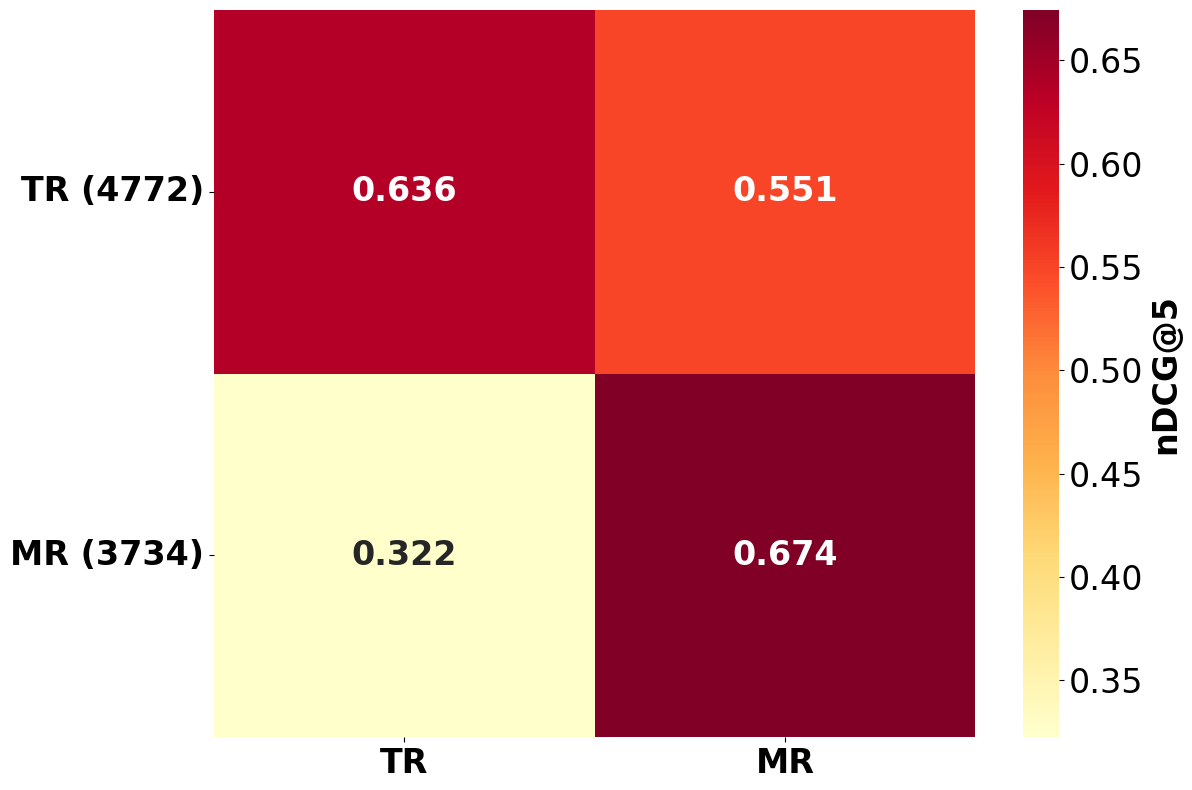

In [25]:
plot_reward_heatmap(oracle, dataset, lambda_val=0.1)

# NDCG - Latency Scatter Plot

In [16]:
import numpy as np
# Store mean NDCG and latency for base pipelines and RAG-MIXER variants
ndcg_latency_data = []

# Add base pipelines
base_pipelines = ["TEXT-SINGLE", "TEXT-MULTI", "MULTIMODAL-SINGLE", "MULTIMODAL-MULTI", "MULTIMODAL_RERANK", "TEXT_RERANK"]
for pipeline in base_pipelines:
    mean_ndcg = dataset[f"{pipeline}_ndcg"].mean()
    mean_latency = dataset[f"{pipeline}_latency"].mean()
    
    ndcg_latency_data.append({
        'model': pipeline,
        'mean_ndcg': mean_ndcg,
        'mean_latency': mean_latency,
        'type': 'base'
    })

# Read all prediction files for RAG-MIXER variants
# The files are named by lambda values (10 = 0.10, 25 = 0.25, etc.)
prediction_files = {
    '0.0': 'predictions/predictions_rerank.xlsx',
}

# Pipelines used by the router (rerank only)
router_pipelines = ["TEXT_RERANK", "MULTIMODAL_RERANK"]

for lambda_val, filename in prediction_files.items():
    # Read predictions
    preds = pd.read_excel(filename, index_col="query")
    preds = preds[preds.index.isin(dataset.index)]
    
    # Build RAG-MIXER predictions for this file
    predicted_ndcgs = []
    predicted_latencies = []
    for idx, row in preds.iterrows():
        predicted_arm = int(row["predicted_label"])
        pipeline = router_pipelines[predicted_arm]
        predicted_ndcgs.append(dataset.loc[idx, f"{pipeline}_ndcg"])
        predicted_latencies.append(dataset.loc[idx, f"{pipeline}_latency"])
    
    mean_ndcg = np.mean(predicted_ndcgs)
    mean_latency = np.mean(predicted_latencies)
    
    ndcg_latency_data.append({
        'model': f'RAG-MIXER',
        'mean_ndcg': mean_ndcg,
        'mean_latency': mean_latency,
        'type': 'rag-mixer'
    })

# Add Oracle with different lambda values
import numpy as np

# First, normalize latency across router pipelines for reward calculation
all_latencies = []
for pipeline in router_pipelines:
    all_latencies.extend(dataset[f"{pipeline}_latency"].dropna().values)
max_latency = np.max(all_latencies)
min_latency = np.min(all_latencies)

for lambda_val in np.arange(0.0, 1.05, 0.1):
    # For each query, select the pipeline with the best reward
    oracle_ndcgs = []
    oracle_latencies = []
    
    for idx, row in dataset.iterrows():
        best_reward = -np.inf
        best_ndcg = None
        best_latency = None
        
        for pipeline in router_pipelines:
            ndcg = row[f"{pipeline}_ndcg"]
            latency = row[f"{pipeline}_latency"]
            
            if pd.notna(ndcg) and pd.notna(latency):
                # Normalize latency
                normalized_latency = (latency - min_latency) / (max_latency - min_latency)
                # Calculate reward
                reward = (1 - lambda_val) * ndcg - lambda_val * normalized_latency
                
                if reward > best_reward:
                    best_reward = reward
                    best_ndcg = ndcg
                    best_latency = latency
        
        if best_ndcg is not None:
            oracle_ndcgs.append(best_ndcg)
            oracle_latencies.append(best_latency)
    
    mean_ndcg = np.mean(oracle_ndcgs)
    mean_latency = np.mean(oracle_latencies)
    
    ndcg_latency_data.append({
        'model': f'Oracle-λ{lambda_val:.2f}',
        'mean_ndcg': mean_ndcg,
        'mean_latency': mean_latency,
        'type': 'oracle'
    })

# Create DataFrame
scatter_df = pd.DataFrame(ndcg_latency_data)
print(scatter_df)

                model  mean_ndcg  mean_latency       type
0         TEXT-SINGLE   0.492429      0.455017       base
1          TEXT-MULTI   0.596482      2.796394       base
2   MULTIMODAL-SINGLE   0.666021      0.384490       base
3    MULTIMODAL-MULTI   0.736669      8.283272       base
4   MULTIMODAL_RERANK   0.732981      1.120659       base
5         TEXT_RERANK   0.604293      0.924289       base
6           RAG-MIXER   0.740713      1.087302  rag-mixer
7        Oracle-λ0.00   0.777004      0.978379     oracle
8        Oracle-λ0.10   0.777004      0.937720     oracle
9        Oracle-λ0.20   0.777004      0.937720     oracle
10       Oracle-λ0.30   0.777004      0.937720     oracle
11       Oracle-λ0.40   0.776930      0.935173     oracle
12       Oracle-λ0.50   0.776919      0.934922     oracle
13       Oracle-λ0.60   0.776919      0.934922     oracle
14       Oracle-λ0.70   0.776875      0.934390     oracle
15       Oracle-λ0.80   0.776664      0.932912     oracle
16       Oracl

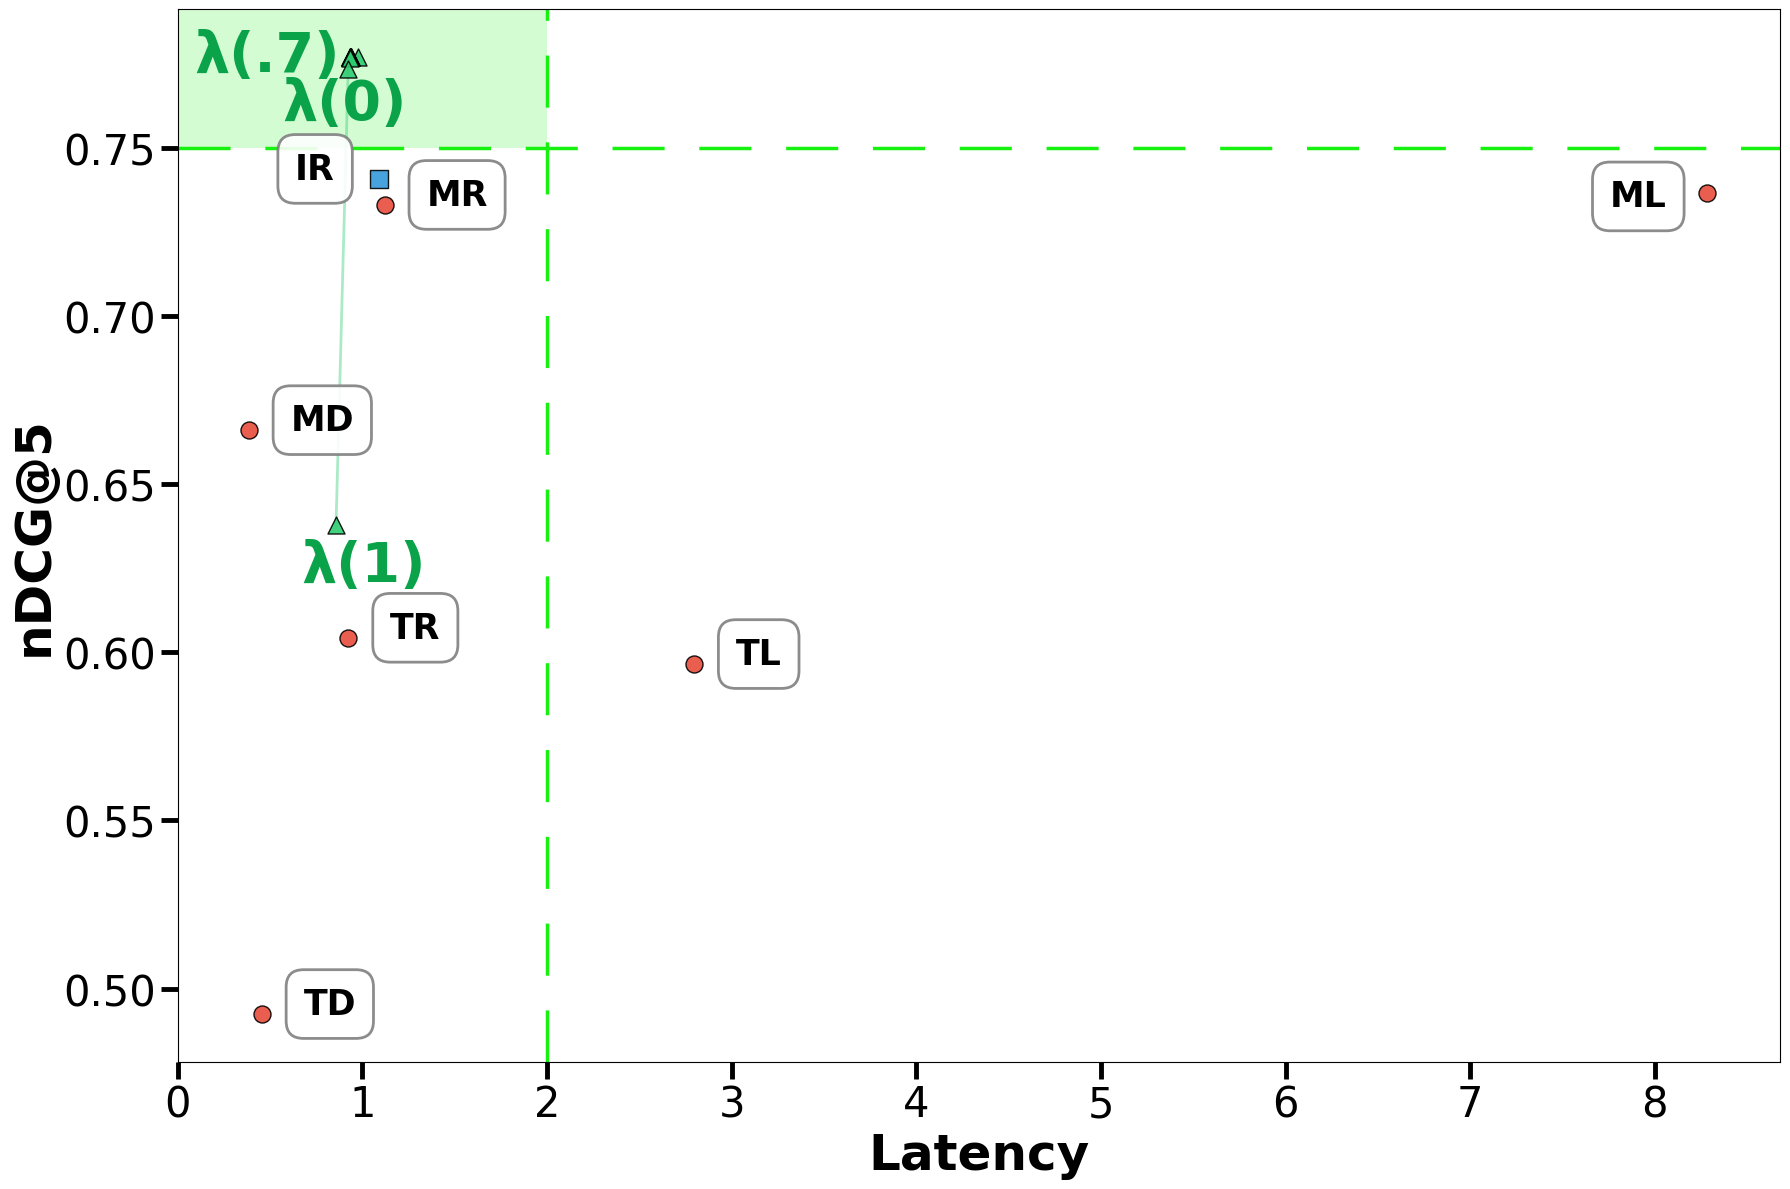

In [27]:
# Create scatter plot with different colors for base pipelines, RAG-MIXER variants, and Oracle
from adjustText import adjust_text
from matplotlib.patches import Patch, Rectangle

plt.figure(figsize=(18, 12))
ax = plt.gca()

# -------------------------------------------------
# Plot Oracle variants (plot first to appear first in legend)
# -------------------------------------------------
oracle_data = scatter_df[scatter_df['type'] == 'oracle']
plt.scatter(
    oracle_data['mean_latency'], oracle_data['mean_ndcg'],
    s=150, alpha=0.9, color='#2ecc71', marker='^',
    label='Oracle', zorder=3,
    edgecolors='black', linewidths=1
)

# Connect Oracle points
oracle_data_sorted = oracle_data.sort_values('mean_latency')
plt.plot(
    oracle_data_sorted['mean_latency'],
    oracle_data_sorted['mean_ndcg'],
    color='#2ecc71', alpha=0.4, linewidth=2, zorder=2
)

# -------------------------------------------------
# Add lambda labels for Oracle (selected lambdas, alternating above/below)
# -------------------------------------------------
oracle_label_config = {
    '0.00': {'offset': (-10, -45), 'ha': 'center'},
    '0.70': {'offset': (-60, -10), 'ha': 'center'},
    '1.00': {'offset': (20, -40), 'ha': 'center'},
}

for _, row in scatter_df.iterrows():
    if row['type'] == 'oracle':
        lambda_str = row['model'].replace('Oracle-λ', '')
        if lambda_str in oracle_label_config:
            config = oracle_label_config[lambda_str]
            if lambda_str == '0.00':
                label = 'λ(0)'
            elif lambda_str == '1.00':
                label = 'λ(1)'
            else:
                label = f"λ({lambda_str.rstrip('0').lstrip('0')})"
            plt.annotate(
                label,
                (row['mean_latency'], row['mean_ndcg']),
                xytext=config['offset'],
                textcoords='offset points',
                fontsize=40, fontweight='bold',
                color="#0AA34A",
                ha=config['ha']
            )

# -------------------------------------------------
# Plot RAG-MIXER variants
# -------------------------------------------------
rag_mixer_data = scatter_df[scatter_df['type'] == 'rag-mixer']
plt.scatter(
    rag_mixer_data['mean_latency'], rag_mixer_data['mean_ndcg'],
    s=150, alpha=0.9, color='#3498db', marker='s',
    label='IRouterLM', zorder=3,
    edgecolors='black', linewidths=1
)

# Connect RAG-MIXER points
rag_mixer_data_sorted = rag_mixer_data.sort_values('mean_latency')
plt.plot(
    rag_mixer_data_sorted['mean_latency'],
    rag_mixer_data_sorted['mean_ndcg'],
    color='#3498db', alpha=0.4, linewidth=2, zorder=2
)

# -------------------------------------------------
# Add lambda labels for IRouterLM (selected lambdas only)
# -------------------------------------------------
lambda_label_config = {
    '0.0': {'offset': (-50, -50), 'ha': 'left'},
    '0.1': {'offset': (10, 25), 'ha': 'center'},
    '0.3': {'offset': (15, -50), 'ha': 'center'},
    '0.5': {'offset': (0, 25), 'ha': 'center'},
    '1': {'offset': (50, -60), 'ha': 'right'},
}

# for _, row in scatter_df.iterrows():
#     if row['type'] == 'rag-mixer':
#         lambda_str = row['model'].replace('RAG-MIXER-λ', '')
#         if lambda_str in lambda_label_config:
#             config = lambda_label_config[lambda_str]
#             if lambda_str == '0.0':
#                 label = 'λ(0)'
#             elif lambda_str == '1.0':
#                 label = 'λ(1)'
#             else:
#                 label = f"λ({lambda_str.lstrip('0')})"
#             plt.annotate(
#                 label,
#                 (row['mean_latency'], row['mean_ndcg']),
#                 xytext=config['offset'],
#                 textcoords='offset points',
#                 fontsize=40, fontweight='bold',
#                 color='#3498db',
#                 ha=config['ha']
#             )

# -------------------------------------------------
# Plot base pipelines (with legend label)
# -------------------------------------------------
base_data = scatter_df[scatter_df['type'] == 'base']
plt.scatter(
    base_data['mean_latency'], base_data['mean_ndcg'],
    s=150, alpha=0.9, color='#e74c3c', marker='o',
    label='', zorder=3,
    edgecolors='black', linewidths=1
)

# -------------------------------------------------
# Labels for base pipelines (fixed positions)
# -------------------------------------------------
for _, row in scatter_df.iterrows():
    if row['type'] != 'oracle':
        label = row['model'].replace('TEXT-SINGLE', 'TD') \
                            .replace('TEXT-MULTI', 'TL') \
                            .replace('MULTIMODAL-SINGLE', 'MD') \
                            .replace('MULTIMODAL-MULTI', 'ML') \
                            .replace('MULTIMODAL_RERANK', 'MR') \
                            .replace('TEXT_RERANK', 'TR') \
                            .replace('RAG-MIXER', 'IR')
        
        # Put ML label to the left, others to the right
        if label == 'ML':
            offset = (-70, -10)
        else:
            offset = (30, 0)

        if label == "IR":
            offset = (-60, 0)
        
        plt.annotate(
            label,
            (row['mean_latency'], row['mean_ndcg']),
            xytext=offset,
            textcoords='offset points',
            fontsize=25, fontweight='bold',
            bbox=dict(
                boxstyle='round,pad=0.5',
                facecolor='white',
                edgecolor='gray',
                alpha=0.9,
                linewidth=2
            )
        )

# -------------------------------------------------
# Axes, legend, styling
# -------------------------------------------------
plt.xlabel('Latency', fontsize=36, fontweight='bold')
plt.ylabel('nDCG@5', fontsize=36, fontweight='bold')

# Set x-axis to start at 0
ax.set_xlim(left=0)

# -------------------------------------------------
# Desired region: NDCG >= 0.75 and Latency <= 2
# -------------------------------------------------
ylim = ax.get_ylim()

desired_rect = Rectangle(
    (0, 0.75), 2, ylim[1] - 0.75,
    facecolor='#16f10f', alpha=0.18, zorder=0
)
ax.add_patch(desired_rect)

ax.axhline(y=0.75, color='#16f10f', linestyle='--', linewidth=2.5, zorder=1, dashes=(15, 10))
ax.axvline(x=2, color='#16f10f', linestyle='--', linewidth=2.5, zorder=1, dashes=(15, 10))

desired_patch = Patch(
    facecolor="#0ff138",
    edgecolor="#16f10f",
    alpha=0.5,
    label=''
)

handles, labels = ax.get_legend_handles_labels()
handles = handles + [desired_patch] 
labels = labels 

# plt.legend(
#     handles,
#     labels,
#     fontsize=30,
#     loc='best',
#     frameon=False,
#     markerscale=3
# )

ax.grid(False)

plt.tick_params(axis='both', which='major', labelsize=22, width=2, length=8)

plt.tick_params(
    axis='both',
    which='major',
    labelsize=30,
    width=3.5,
    length=12
)

plt.tight_layout()
plt.show()